In [1]:
!pip install pandas openpyxl

In [2]:
import pandas as pd
df = pd.read_excel('charts_group_project.xlsb')
df.head()

,date,country,position,streams,track_id,artists,artist_genres,duration,explicit,name
0,44875,au,169,280161,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up
1,44875,be,182,59603,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up
2,44875,ie,184,46016,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up
3,44875,cz,198,43421,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up
4,44868,be,159,62915,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up


In [4]:
import ast

def safe_eval_genre(s):
    try:
        return ast.literal_eval(s)
    except:
        return []

df['artist_genres_list'] = df['artist_genres'].apply(safe_eval_genre)

In [5]:
genre_map = {
    "pop": ["pop", "pop rap", "pop dance", "dance pop", "electropop", "uk pop", "viral pop", "canadian pop"],
    "hip hop/rap": ["hip hop", "rap", "trap", "pop rap", "latin hip hop", "southern hip hop", "gangster rap"],
    "electronic/dance": ["edm", "electro house", "house", "progressive house", "tropical house", "trance", "complextro"],
    "latin": ["reggaeton", "bachata", "cumbia", "latin pop", "urbano latino"],
    "r&b/soul": ["r&b", "neo soul", "contemporary r&b", "chill r&b", "pop r&b"],
    "rock": ["rock", "pop rock", "modern rock", "alternative rock", "indie rock"],
    "country/folk": ["country", "country pop", "folk pop"],
    "global/regional": ["k-pop", "j-pop", "mandopop", "italian pop", "french pop"],
    "alternative/indie": ["indie pop", "indie poptimism", "bedroom pop", "alt z", "art pop"],
    "reggae/dancehall": ["dancehall", "moombahton", "tropical"]
}

In [6]:
def assign_main_genre(genres):
    if not genres:
        return "Other"
    
    genres = [g.lower() for g in genres]
    
    for main_genre, subgenres in genre_map.items():
        for sub in subgenres:
            if any(sub == g or sub in g for g in genres):
                return main_genre.capitalize()
    return "Other"

In [7]:
df['main_genre'] = df['artist_genres_list'].apply(assign_main_genre)

In [8]:
df.head()

,date,country,position,streams,track_id,artists,artist_genres,duration,explicit,name,artist_genres_list,main_genre
0,44875,au,169,280161,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up,"[pop rap, pop, pop dance, dance pop, edm]",Pop
1,44875,be,182,59603,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up,"[pop rap, pop, pop dance, dance pop, edm]",Pop
2,44875,ie,184,46016,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up,"[pop rap, pop, pop dance, dance pop, edm]",Pop
3,44875,cz,198,43421,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up,"[pop rap, pop, pop dance, dance pop, edm]",Pop
4,44868,be,159,62915,0nrRP2bk19rLc0orkWPQk2,['Avicii'],"['pop rap', 'pop', 'pop dance', 'dance pop', '...",247426,False,Wake Me Up,"[pop rap, pop, pop dance, dance pop, edm]",Pop


In [10]:
df = df.drop(columns=['artist_genres', 'artist_genres_list'])

In [11]:
df.head()

,date,country,position,streams,track_id,artists,duration,explicit,name,main_genre
0,44875,au,169,280161,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
1,44875,be,182,59603,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
2,44875,ie,184,46016,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
3,44875,cz,198,43421,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
4,44868,be,159,62915,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop


In [12]:
df.nunique()

date             515
country           77
position         336
streams       375371
track_id       21518
artists        13686
duration       17581
explicit           2
name           19274
main_genre        10
dtype: int64

In [13]:
df.duplicated().sum() #no duplicates

np.int64(0)

In [14]:
df.info() #no missing values(only in artist name but we don't need that)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   date        1048575 non-null  int64 
 1   country     1048575 non-null  object
 2   position    1048575 non-null  int64 
 3   streams     1048575 non-null  int64 
 4   track_id    1048575 non-null  object
 5   artists     1048575 non-null  object
 6   duration    1048575 non-null  int64 
 7   explicit    1048575 non-null  bool  
 8   name        1048388 non-null  object
 9   main_genre  1048575 non-null  object
dtypes: bool(1), int64(4), object(5)
memory usage: 73.0+ MB


In [15]:
#created a new column with just the year
df['date'] = pd.to_datetime(df['date'], origin='1899-12-30', unit='D').dt.year
df.head()

,date,country,position,streams,track_id,artists,duration,explicit,name,main_genre
0,2022,au,169,280161,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
1,2022,be,182,59603,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
2,2022,ie,184,46016,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
3,2022,cz,198,43421,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
4,2022,be,159,62915,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop


In [16]:
!pip install pycountry

In [17]:
#fixing country names
import pycountry

def get_country_name(code):
    try:
        return pycountry.countries.get(alpha_2=code.upper()).name
    except:
        return code  # keeps values like 'global' unchanged

df['country'] = df['country'].apply(get_country_name)
df.head()

,date,country,position,streams,track_id,artists,duration,explicit,name,main_genre
0,2022,Australia,169,280161,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
1,2022,Belgium,182,59603,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
2,2022,Ireland,184,46016,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
3,2022,Czechia,198,43421,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop
4,2022,Belgium,159,62915,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop


In [18]:
import ast

def safe_eval_artists(s):
    try:
        return ast.literal_eval(s)
    except:
        return []
    
df['artists_list'] = df['artists'].apply(safe_eval_artists)

In [19]:
def first_artist(artist_list):
    if artist_list:
        return artist_list[0]
    return None  # or "" if you prefer an empty string

df['artist_name'] = df['artists_list'].apply(first_artist)

In [20]:
df.head()

,date,country,position,streams,track_id,artists,duration,explicit,name,main_genre,artists_list,artist_name
0,2022,Australia,169,280161,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop,[Avicii],Avicii
1,2022,Belgium,182,59603,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop,[Avicii],Avicii
2,2022,Ireland,184,46016,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop,[Avicii],Avicii
3,2022,Czechia,198,43421,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop,[Avicii],Avicii
4,2022,Belgium,159,62915,0nrRP2bk19rLc0orkWPQk2,['Avicii'],247426,False,Wake Me Up,Pop,[Avicii],Avicii


In [21]:
df.drop(columns=['artists', 'artists_list'], inplace=True)

In [22]:
df.head()

,date,country,position,streams,track_id,duration,explicit,name,main_genre,artist_name
0,2022,Australia,169,280161,0nrRP2bk19rLc0orkWPQk2,247426,False,Wake Me Up,Pop,Avicii
1,2022,Belgium,182,59603,0nrRP2bk19rLc0orkWPQk2,247426,False,Wake Me Up,Pop,Avicii
2,2022,Ireland,184,46016,0nrRP2bk19rLc0orkWPQk2,247426,False,Wake Me Up,Pop,Avicii
3,2022,Czechia,198,43421,0nrRP2bk19rLc0orkWPQk2,247426,False,Wake Me Up,Pop,Avicii
4,2022,Belgium,159,62915,0nrRP2bk19rLc0orkWPQk2,247426,False,Wake Me Up,Pop,Avicii


In [39]:
df['date'].unique()

array([2022, 2013, 2020, 2021, 2019, 2018, 2017, 2023, 2014, 2015, 2016],
      dtype=int32)

In [23]:
df.rename(columns={'main_genre': 'genre_name'}, inplace=True)
df.rename(columns={'track_id': 'trackID'}, inplace=True)
df.rename(columns={'name': 'title'}, inplace=True)

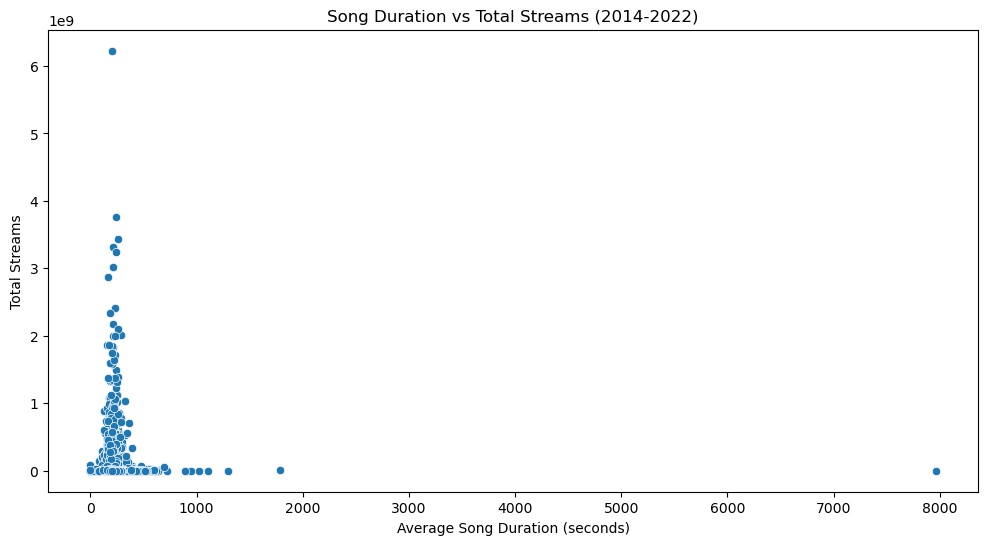

C:\Users\franc\AppData\Local\Temp\ipykernel_32752\2237065772.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = song_stats.groupby('duration_bin')['total_streams'].mean().reset_index()
C:\Users\franc\AppData\Local\Temp\ipykernel_32752\2237065772.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bin_stats, x='duration_bin', y='total_streams', palette='viridis')


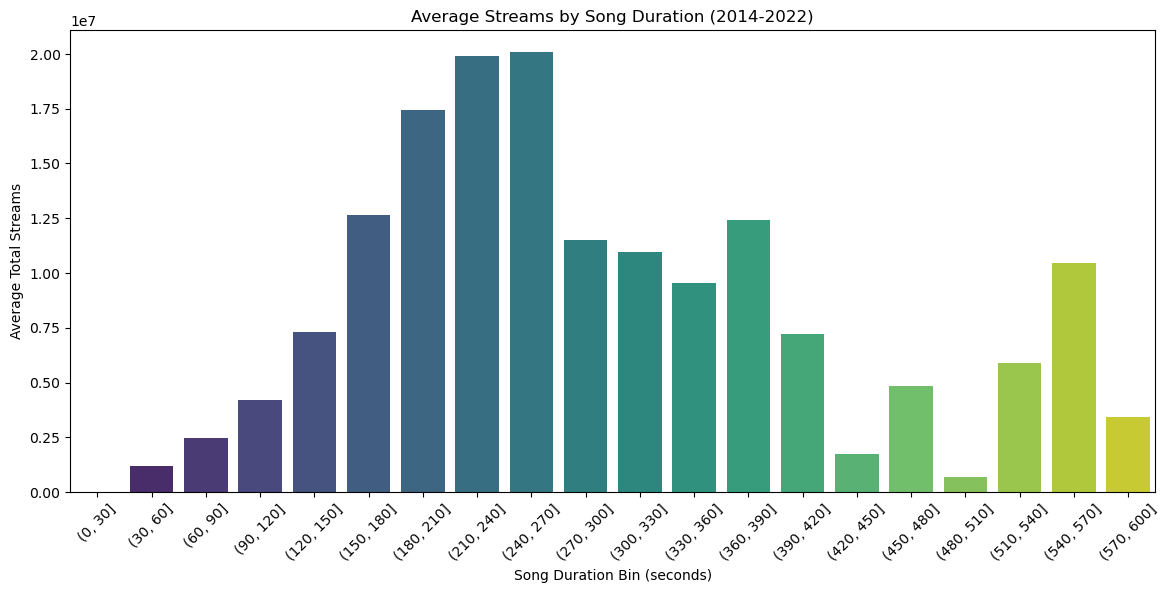

Correlation between song duration and total streams: 0.01


In [52]:
# TESTING HYPOTHESIS1

# --- IMPORTS ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PREPARE DATA ---
# Make sure your cleaned DataFrame is loaded as df
# Convert 'duration' from milliseconds to seconds if needed
df['duration_sec'] = df['duration'] / 1000

# Filter for years 2014-2022
df_analysis = df[(df['date'] >= 2014) & (df['date'] <= 2022)]

# --- AGGREGATE PER SONG ---
# Group by track_id to get average duration and total streams
song_stats = df_analysis.groupby('trackID').agg(
    avg_duration_sec=('duration_sec', 'mean'),
    total_streams=('streams', 'sum'),
    name=('title', 'first')  # Keep song title
).reset_index()

# --- SCATTER PLOT: Duration vs Total Streams ---
plt.figure(figsize=(12,6))
sns.scatterplot(data=song_stats, x='avg_duration_sec', y='total_streams')
plt.xlabel("Average Song Duration (seconds)")
plt.ylabel("Total Streams")
plt.title("Song Duration vs Total Streams (2014-2022)")
plt.show()

# --- BIN DURATION FOR AVERAGE STREAMS PER LENGTH RANGE ---
# Create bins (e.g., every 30 seconds)
bins = range(0, 601, 30)  # up to 10 min
song_stats['duration_bin'] = pd.cut(song_stats['avg_duration_sec'], bins)

# Compute average streams per bin
bin_stats = song_stats.groupby('duration_bin')['total_streams'].mean().reset_index()

# --- BAR PLOT: Average Streams per Duration Bin ---
plt.figure(figsize=(14,6))
sns.barplot(data=bin_stats, x='duration_bin', y='total_streams', palette='viridis')
plt.xticks(rotation=45)
plt.xlabel("Song Duration Bin (seconds)")
plt.ylabel("Average Total Streams")
plt.title("Average Streams by Song Duration (2014-2022)")
plt.show()

# --- OPTIONAL: CORRELATION ---
corr = song_stats['avg_duration_sec'].corr(song_stats['total_streams'])
print(f"Correlation between song duration and total streams: {corr:.2f}")

In [ ]:
#Positive correlation → longer songs tend to get more streams
#Negative correlation → shorter songs are more popular
#Near zero → no clear linear relationship

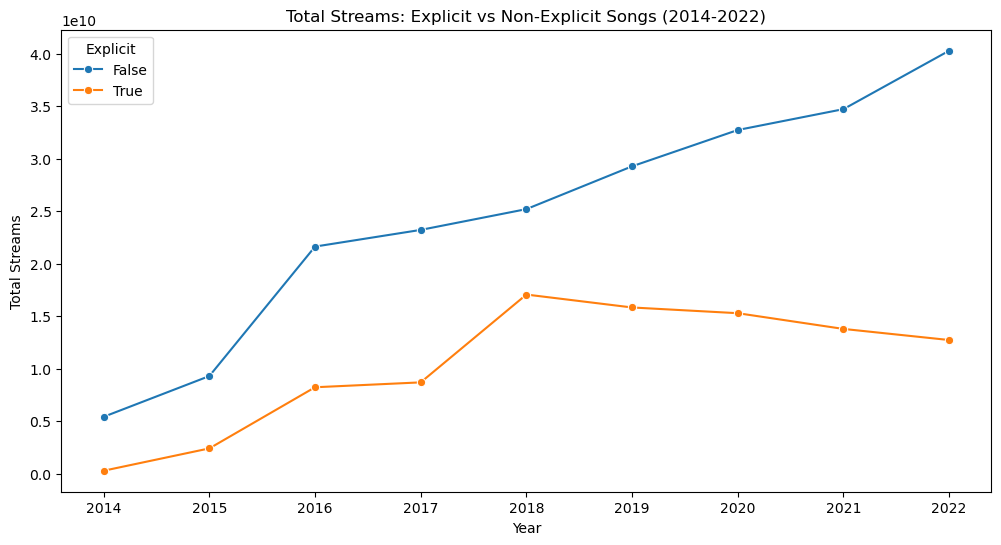

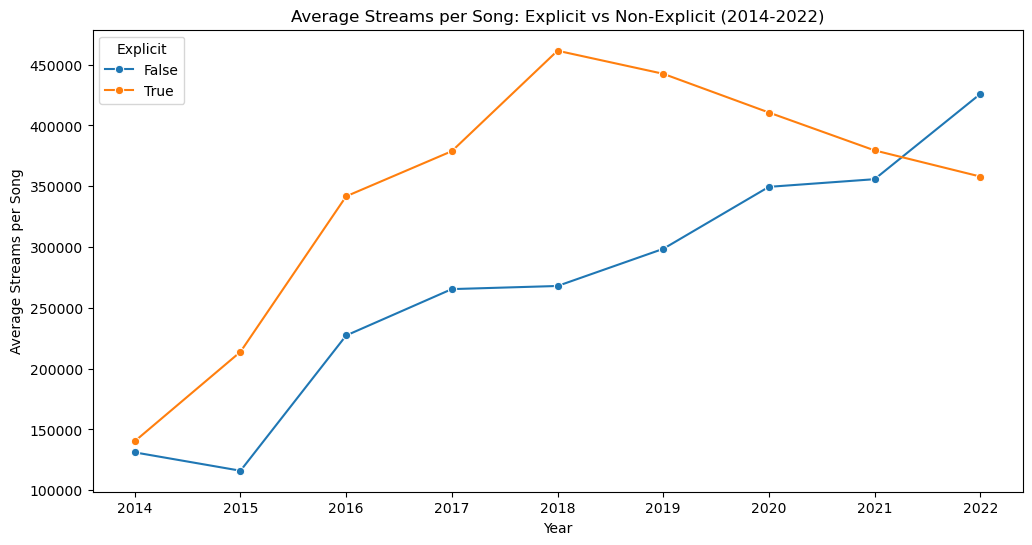

C:\Users\franc\AppData\Local\Temp\ipykernel_32752\1189565013.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


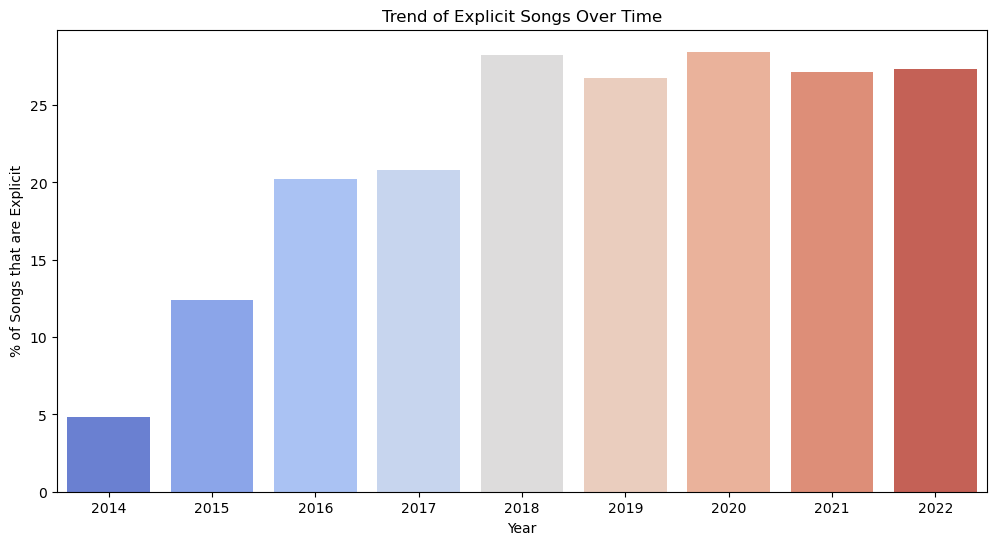

In [53]:
# Testing hypothesis2
# Filter years if needed
df_analysis = df[(df['date'] >= 2014) & (df['date'] <= 2022)]

explicit_stats = df_analysis.groupby(['date', 'explicit']).agg(
    total_streams=('streams', 'sum'),
    avg_streams=('streams', 'mean'),
    num_songs=('trackID', 'count')
).reset_index()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(
    data=explicit_stats,
    x='date',
    y='total_streams',
    hue='explicit',
    marker='o'
)
plt.xlabel("Year")
plt.ylabel("Total Streams")
plt.title("Total Streams: Explicit vs Non-Explicit Songs (2014-2022)")
plt.legend(title='Explicit')
plt.show()

plt.figure(figsize=(12,6))
sns.lineplot(
    data=explicit_stats,
    x='date',
    y='avg_streams',
    hue='explicit',
    marker='o'
)
plt.xlabel("Year")
plt.ylabel("Average Streams per Song")
plt.title("Average Streams per Song: Explicit vs Non-Explicit (2014-2022)")
plt.legend(title='Explicit')
plt.show()

explicit_prop = df_analysis.groupby('date')['explicit'].mean().reset_index()
explicit_prop['explicit_percent'] = explicit_prop['explicit'] * 100

plt.figure(figsize=(12,6))
sns.barplot(
    data=explicit_prop,
    x='date',
    y='explicit_percent',
    palette='coolwarm'
)
plt.xlabel("Year")
plt.ylabel("% of Songs that are Explicit")
plt.title("Trend of Explicit Songs Over Time")
plt.show()

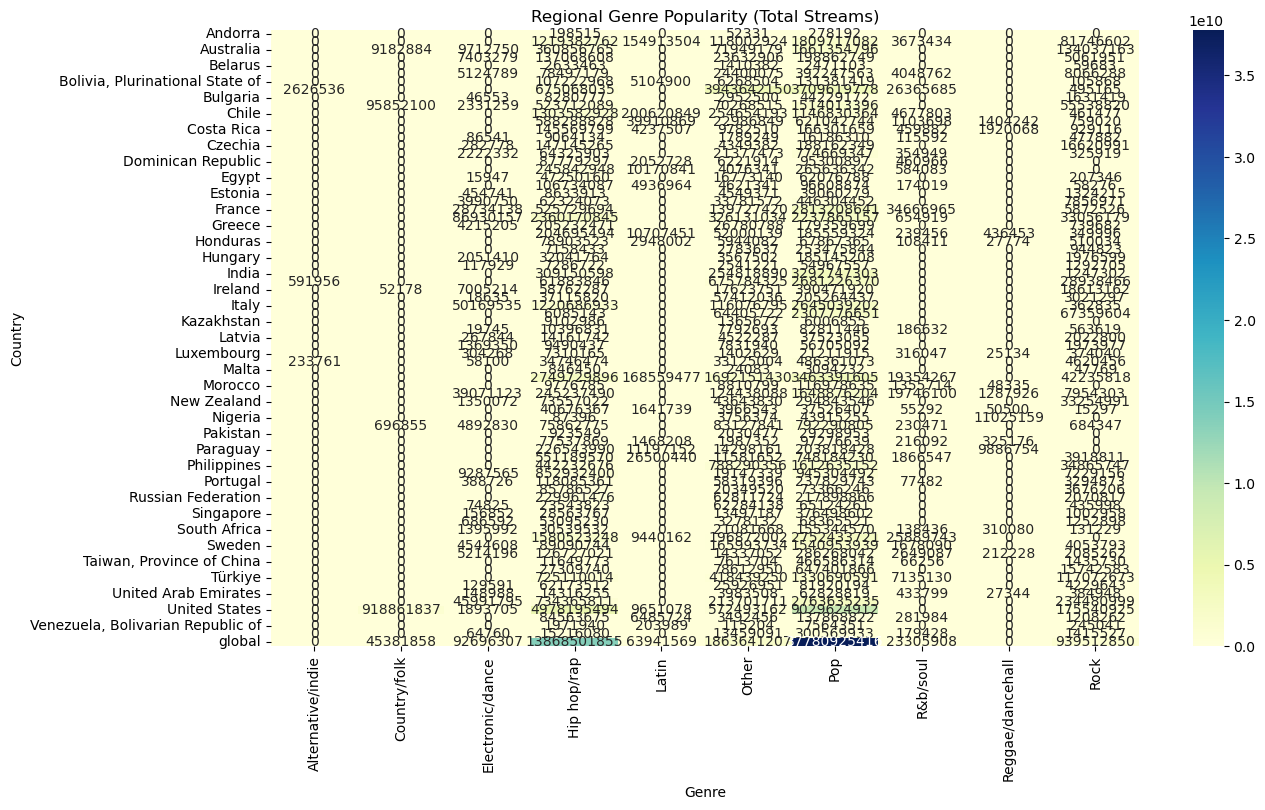

,country,genre_name,total_streams,avg_streams,num_songs,genre_share
153,Hong Kong,Pop,253475844,51104.000806,4960,95.881835
356,"Taiwan, Province of China",Pop,466586314,89470.050623,5215,95.739122
192,Japan,Pop,2307776651,423289.921313,5452,94.363390
273,Pakistan,Pop,29298953,48831.588333,600,90.841075
406,Viet Nam,Pop,300569933,58374.428627,5149,90.832746
86,Denmark,Pop,774669347,136891.561583,5659,89.736007
322,Singapore,Pop,376498602,79919.040968,4711,89.702461
224,Malaysia,Pop,486361073,95815.814224,5076,86.983017
238,Morocco,Pop,116978635,25675.732002,4556,85.404400
167,India,Pop,3292747303,679617.606398,4845,85.349351


In [50]:
#Testing BONUS HYPOTHESIS
# Filter years 2020-2023 if desired
df_region = df[(df['date'] >= 2020) & (df['date'] <= 2023)]

regional_stats = df_region.groupby(['country', 'genre_name']).agg(
    total_streams=('streams', 'sum'),
    avg_streams=('streams', 'mean'),
    num_songs=('trackID', 'count')
).reset_index()

# Create a pivot table: countries x genres
pivot = regional_stats.pivot(index='country', columns='genre_name', values='total_streams').fillna(0)

plt.figure(figsize=(14,8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".0f")
plt.xlabel("Genre")
plt.ylabel("Country")
plt.title("Regional Genre Popularity (Total Streams)")
plt.show()

#TOP GENRE PER COUNTRY
top_genre_country = regional_stats.loc[regional_stats.groupby('country')['total_streams'].idxmax()]
top_genre_country = top_genre_country[['country', 'genre_name', 'total_streams']].sort_values('total_streams', ascending=False)
top_genre_country.head(10)

#Proportion of streams per genre in each country
regional_stats['genre_share'] = regional_stats.groupby('country')['total_streams'].transform(lambda x: x / x.sum() * 100)

# Example: Top 5 countries for Pop
regional_stats[regional_stats['genre_name'] == 'Pop'].sort_values('genre_share', ascending=False).head(10)

In [28]:
#df[['genre_name']].to_csv('table_genre.csv', index=False)

In [29]:
#df[['artist_name']].to_csv('table_artist.csv', index=False)

In [30]:
#df[['trackID', 'genre_name']].to_csv('table_track_genre.csv', index=False)

In [31]:
#df[['trackID', 'artist_name']].to_csv('table_track_artist.csv', index=False)

In [32]:
#df[['trackID', 'title', 'explicit', 'duration']].to_csv('table_track.csv', index=False)

In [34]:
#f[['country', 'trackID', 'date', 'streams', 'position']].to_csv('table_charts.csv', index=False)

In [35]:
#df[['country']].to_csv('table_country.csv', index=False)

In [36]:
#import csv

#df.to_csv(
#   "clean_songs.csv",
#    index=False,          # no extra index column
#    sep=",",              # force comma as delimiter
#    encoding="utf-8",     # UTF-8 encoding
#    quoting=csv.QUOTE_ALL # quote all fields (prevents delimiter confusion)
)

In [37]:
#import csv

# Select only the column you want
#df[['genre_name']].to_csv(
#    "genre_only.csv",
#    index=False,          # no extra index column
#    sep=",",              # force comma as delimiter
#    encoding="utf-8",     # UTF-8 encoding
#    quoting=csv.QUOTE_ALL # quote all fields (prevents delimiter confusion)
#)